# **EXPT NO: 5**
# **Student Roll No: 24BAD108**

# **PART A – Dataset Preparation**

In [1]:
# RNN Text Generation

import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

# Set random seed
tf.random.set_seed(42)
np.random.seed(42)

# Download Tiny Shakespeare dataset
url = "https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt"

path = tf.keras.utils.get_file(
    "tiny_shakespeare.txt",
    origin=url
)

# Load text
text = open(path, "r", encoding="utf-8").read()

print("Total characters:", len(text))
print("\nSample text:\n")
print(text[:500])

1115394/1115394 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Total characters: 1115394

Sample text:

First Citizen:
Before we proceed any further, hear me speak.

All:
Speak, speak.

First Citizen:
You are all resolved rather to die than to famish?

All:
Resolved. resolved.

First Citizen:
First, you know Caius Marcius is chief enemy to the people.

All:
We know't, we know't.

First Citizen:
Let us kill him, and we'll have corn at our own price.
Is't a verdict?

All:
No more talking on't; let it be done: away, away!

Second Citizen:
One word, good citizens.

First Citizen:
We are accounted poor


**Use a smaller dataset**

In [2]:
# Use only a portion of the dataset for faster training

text = text[:50000]

# Convert to lowercase
text = text.lower()

print("Characters used:", len(text))
print("\nSample:\n")
print(text[:500])

Characters used: 50000

Sample:

first citizen:
before we proceed any further, hear me speak.

all:
speak, speak.

first citizen:
you are all resolved rather to die than to famish?

all:
resolved. resolved.

first citizen:
first, you know caius marcius is chief enemy to the people.

all:
we know't, we know't.

first citizen:
let us kill him, and we'll have corn at our own price.
is't a verdict?

all:
no more talking on't; let it be done: away, away!

second citizen:
one word, good citizens.

first citizen:
we are accounted poor


**Tokenization**

In [3]:
# Tokenize text into words

words = text.split()

# Create vocabulary
vocabulary = sorted(set(words))

word_to_index = {
    word: index + 1
    for index, word in enumerate(vocabulary)
}

index_to_word = {
    index: word
    for word, index in word_to_index.items()
}

# Convert words to integers
encoded_text = [
    word_to_index[word]
    for word in words
]

print("Total words:", len(words))
print("Vocabulary size:", len(vocabulary))
print("\nFirst 20 encoded words:")
print(encoded_text[:20])

Total words: 8957
Vocabulary size: 2814

First 20 encoded words:
[872, 436, 241, 2648, 1882, 136, 960, 1107, 1493, 2210, 95, 2208, 2210, 872, 436, 2796, 148, 92, 1970, 1928]


**Generate Input Sequences**

In [4]:
# Sequence length
sequence_length = 10

X = []
y = []

for i in range(len(encoded_text) - sequence_length):
    X.append(encoded_text[i:i + sequence_length])
    y.append(encoded_text[i + sequence_length])

X = np.array(X)
y = np.array(y)

print("Input shape:", X.shape)
print("Target shape:", y.shape)

Input shape: (8947, 10)
Target shape: (8947,)


**Train-Validation Split**

In [5]:
# Use a smaller number of sequences for faster training

X = X[:10000]
y = y[:10000]

split = int(0.8 * len(X))

X_train = X[:split]
y_train = y[:split]

X_val = X[split:]
y_val = y[split:]

print("Training samples:", len(X_train))
print("Validation samples:", len(X_val))

Training samples: 7157
Validation samples: 1790


# **PART B – IMPLEMENTING THE RNN MODEL**

In [6]:
# Build RNN Model

vocab_size = len(vocabulary) + 1

model = tf.keras.Sequential([
    tf.keras.layers.Embedding(
        input_dim=vocab_size,
        output_dim=64,
        input_length=sequence_length
    ),

    tf.keras.layers.SimpleRNN(128),

    tf.keras.layers.Dense(
        vocab_size,
        activation='softmax'
    )
])

# Compile model
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Display model architecture
model.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

# **PART C – MODEL TRAINING AND EVALUATION**

In [7]:
# Train the RNN

history = model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=10,
    batch_size=64
)

Epoch 1/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 6s 35ms/step - accuracy: 0.0367 - loss: 7.1627 - val_accuracy: 0.0430 - val_loss: 7.1361
Epoch 2/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 3s 27ms/step - accuracy: 0.0388 - loss: 6.5580 - val_accuracy: 0.0436 - val_loss: 7.4244
Epoch 3/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - accuracy: 0.0411 - loss: 6.4423 - val_accuracy: 0.0430 - val_loss: 7.4804
Epoch 4/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - accuracy: 0.0411 - loss: 6.3326 - val_accuracy: 0.0430 - val_loss: 7.7269
Epoch 5/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - accuracy: 0.0409 - loss: 6.2807 - val_accuracy: 0.0430 - val_loss: 7.9091
Epoch 6/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 3s 28ms/step - accuracy: 0.0411 - loss: 6.3690 - val_accuracy: 0.0369 - val_loss: 7.8218
Epoch 7/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step - accuracy: 0.0405 - loss: 6.2508 - val_accuracy: 0.0318 - val_loss: 7.8236
Epoch 8/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - accuracy: 0.0405 - loss: 6.1837 - val_accu

**Accuracy vs Epoch**

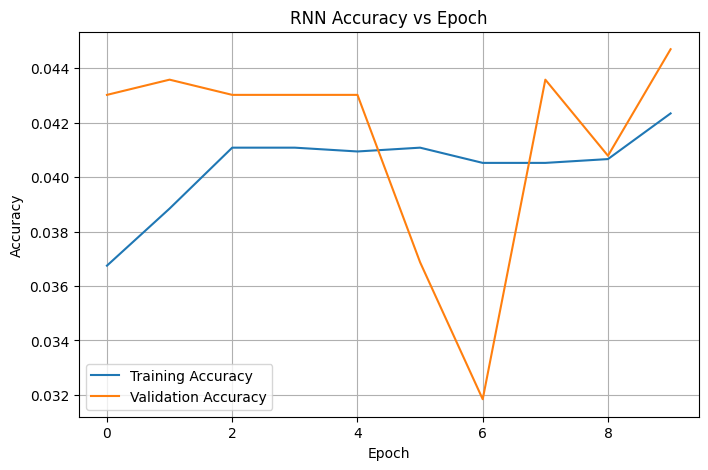

In [8]:
plt.figure(figsize=(8, 5))

plt.plot(
    history.history['accuracy'],
    label='Training Accuracy'
)

plt.plot(
    history.history['val_accuracy'],
    label='Validation Accuracy'
)

plt.title("RNN Accuracy vs Epoch")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

plt.show()

**Loss vs Epoch**

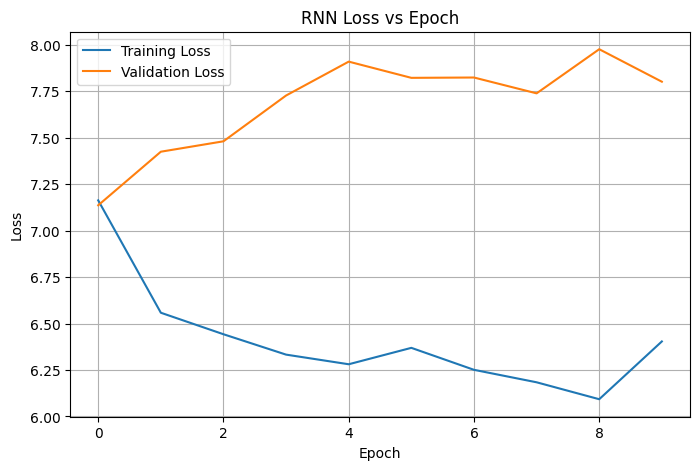

In [9]:
plt.figure(figsize=(8, 5))

plt.plot(
    history.history['loss'],
    label='Training Loss'
)

plt.plot(
    history.history['val_loss'],
    label='Validation Loss'
)

plt.title("RNN Loss vs Epoch")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.show()

# **PART D – TEXT GENERATION**

In [10]:
def generate_text(seed_text, num_words=20):

    seed_words = seed_text.lower().split()

    # Keep only known words
    seed_words = [
        word for word in seed_words
        if word in word_to_index
    ]

    if len(seed_words) < sequence_length:
        print("Please provide at least",
              sequence_length,
              "known words.")
        return

    generated_words = seed_words.copy()

    for _ in range(num_words):

        sequence = generated_words[-sequence_length:]

        encoded_sequence = [
            word_to_index[word]
            for word in sequence
        ]

        encoded_sequence = np.array(
            encoded_sequence
        ).reshape(1, -1)

        prediction = model.predict(
            encoded_sequence,
            verbose=0
        )

        predicted_index = np.argmax(prediction[0])

        if predicted_index == 0:
            break

        predicted_word = index_to_word[predicted_index]

        generated_words.append(predicted_word)

    print("Generated Text:")
    print(" ".join(generated_words))

**Generate Text Using Seed Input**

In [11]:
seed = "the king of the world and"
generate_text(seed, num_words=20)

Please provide at least 10 known words.


**Generate Another Sample**

In [12]:
seed = "i will tell you what"
generate_text(seed, num_words=20)

Please provide at least 10 known words.


**Save the Model**

In [13]:
model.save("rnn_text_generation.keras")

print("Model saved successfully.")

Model saved successfully.


# **GitHub**

In [24]:
!git config --global user.email "shailesh@example.com"
!git config --global user.name "Shailesh-0305"
!git init
!git add .
!git commit -m "Added Transfer Learning Experiment - Local Save"
print("Successfully saved changes to local Git repository.")

Reinitialized existing Git repository in /content/.git/
On branch main
nothing to commit, working tree clean
Successfully saved changes to local Git repository.
